In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

from matplotlib.lines import Line2D
import seaborn as sns

from datetime import datetime as dt
from datetime import timedelta
import os

import matplotlib.cm as cm
import matplotlib.ticker as ticker
pd.options.mode.chained_assignment = None 

In [2]:
from brokenaxes import brokenaxes

In [3]:
import matplotlib
font = {'family' : 'serif',
        'weight' : 'normal',
        'size'   : 18}

matplotlib.rc('font', **font)

In [4]:
folder_name = "C:/Users/s162378/OneDrive - TU Eindhoven/Documents/GitHub/DSCM/Figures/CompareDistributions/"

In [5]:
def read(filename):
    df = pd.read_csv(filename, header = 0)
    return df


In [6]:
def getBins(df):
    maxAnswer = df['exactAnswer'].max()
    bbs = [0.25*maxAnswer, 0.5*maxAnswer, 0.75*maxAnswer]

    for i, v in df.iterrows():
        ex = v['exactAnswer']
        if ex < bbs[0]:
            df.loc[i,'queryBin'] = 0
        elif bbs[0] <= ex < bbs[1]:
            df.loc[i,'queryBin'] = 1
        elif bbs[1] <= ex < bbs[2]:
            df.loc[i,'queryBin'] = 2
        else:
            df.loc[i,'queryBin'] = 3
    return df

In [7]:
def get_used_attrs(df):
    attrs = []
    for i in df['queryText'].unique():
        splitted = i.split(' ')
        for s in splitted:
            if "=" in s:
                continue
            if s.isnumeric():
                continue
            if 'and' in s:
                continue
            if s not in attrs:
                attrs.append(s)
    print(attrs)
    return len(attrs)
    print("{} Distinct attributes used in predicates".format(len(attrs)))
    

In [8]:
def preprocess(df, p, keepAll=False):
    def replace_comma_with_dot_and_convert_to_float(column_name):
        if column_name in df.columns[df.dtypes == 'object']:
            df[column_name] = df[column_name].str.replace(',', '.').astype({column_name: float})

    replace_comma_with_dot_and_convert_to_float('relError')
    replace_comma_with_dot_and_convert_to_float('epsError')

    df['Sketch Memory (MB)'] = df['memUsageSynopsis'] / 1e6
    df['Dataset Memory (MB)'] = df['memUsageDataset'] / 1e6
    df['Speedup'] = df['exactTime'] / df['estTime']
    df['Time Est (ms)'] = df['estTime']
    df['Ingestion Time'] = df['Avg Update Time']* 5e6 / 1000
    df['Time exact (ms)'] = df['exactTime']
    df['relMemFootprint'] = df['Sketch Memory (MB)'] / df['Dataset Memory (MB)']
    df['thrm33case2'] = np.where(df['setting'] != 'OmniSketch', True, df['thrm33case2'])
    df['RAM'] = df['RAM'] / (8e6)

    if not keepAll:
        df = df[df['numPredicates'] == p]

    df['altAbsError'] = np.where(df['setting'] == 'OmniSketch',
                                 abs(df['case2Estimate'] - df['exactAnswer']),
                                 df['absError'])
    df['altEpsError'] = df['altAbsError'] / df['streamSize']  # Alternative epsError.
    df['altNullAbsError'] = np.where(df['thrm33case2'] == False,
                                     df['exactAnswer'],
                                     abs(df['estimate'] - df['exactAnswer']))
    df['altNullEpsError'] = df['altNullAbsError'] / df['streamSize']
    df['d'], df['w'], df['B'], df['b'] = 0, 0, 0, 0

    for k, v in df.iterrows():
        pars = [int(i) for i in list(v['parameters'].replace("[", "").replace("]", "").split(", "))]
        if v['setting'] == "OmniSketch":
            df.loc[k, 'd'], df.loc[k, 'w'], df.loc[k, 'B'], df.loc[k, 'b'] = pars

    df['histSetting'] = df['setting'] + df['RAM'].astype(str)
    setting_map = {
        'p0.0': 'p', 'n0.0': 'n', '.0': '',
        'Sketch0Cap': r'$\mathbb{S}0_{\cap}$',
        'Sketch0Min': r'$\mathbb{S}0_{\min}$',
        'OmniSketch10': r'$\mathbb{S}1 (10 MB)$',
        'OmniSketch50': r'$\mathbb{S}1 (50 MB)$',
        'OmniSketch100': r'$\mathbb{S}1 (100 MB)$',
        'OmniSketch200': r'$\mathbb{S}1 (200 MB)$',
        'Hydra10': 'Hydra (10 MB)',
        'Hydra50': 'Hydra (50 MB)',
        'Hydra100': 'Hydra (100 MB)',
        'Hydra200': 'Hydra (200 MB)'
    }
    df['histSetting'] = df['histSetting'].replace(setting_map)

    for numAttrs in df['numAttributes'].unique():
        dfa = df[df['numAttributes'] == numAttrs]
        usedAttrs = get_used_attrs(dfa)
        df.loc[df['numAttributes'] == numAttrs, 'numAttributesInWorkload'] = usedAttrs

    return df

# Numbers to compute for table
- Avg ingestion time
- Avg exec time
- Avg accuracy

- Setting:
    - 10 MB, 50 MB
    - All queries have p = |A|
    

In [9]:
folder = "outputODC/FinalSensitivity/newest/"
date =  "2023-08-25"
repetition=2
file_zipf13 = "results_Compare Distributions_synthzipf1-3_{}_Rep{}.csv".format(date, repetition)
file_zipf15 ="results_Compare Distributions_synthzipf1-5_{}_Rep{}.csv".format(date, repetition)
file_zipf1 = "results_Compare Distributions_synthzipf1_{}_Rep{}.csv".format(date, repetition)
file_unif = "results_Compare Distributions_synthUniform_{}_Rep{}.csv".format(date, repetition)
file_caida = "results_Compare Distributions_CAIDA_{}_Rep{}.csv".format(date, repetition)
file_snmp = "results_Compare Distributions_SNMP_{}_Rep{}.csv".format(date, repetition)

In [10]:
dataset = 'synth'

In [11]:
import random
def select_450_queries(df):
    dfq = df[df['RAM'] == 50]
    dfq = dfq[dfq['numPredicates'] == 3]
    #dfq = dfq[dfq['numAttributes'] == 8]
    dfq = dfq[dfq['setting'] == 'OmniSketch']
    unq_qs = dfq['queryText'].unique()
    random_entries = random.sample(unq_qs.tolist(), min(450, len(unq_qs)))
    print(len(random_entries))
    # Create a DataFrame containing the selected random entries
    selected_df = df[df['queryText'].isin(random_entries)]

    return selected_df


In [12]:
def get(filename):
    print(filename)
    path = 'outputODC/FinalSensitivity/'
    df = read(path + filename)
    df = preprocess(df, 2, True)
    select_450_queries(df)
    return df
df_zipf1 = get(file_zipf1)
df_zipf13 = get(file_zipf13)
df_zipf15 = get(file_zipf15)
df_unif = get(file_unif)
df_caida = get(file_caida)
df_snmp = get(file_snmp)

results_Compare Distributions_synthzipf1_2023-08-25_Rep2.csv
[]
450
results_Compare Distributions_synthzipf1-3_2023-08-25_Rep2.csv
[]
450
results_Compare Distributions_synthzipf1-5_2023-08-25_Rep2.csv
[]
450
results_Compare Distributions_synthUniform_2023-08-25_Rep2.csv
[]
450
results_Compare Distributions_CAIDA_2023-08-25_Rep2.csv
['ipSrcHost', 'ipDstNet', 'ipSrc', 'ipDstHost', 'ipDst', 'ipSrcNet']
450
results_Compare Distributions_SNMP_2023-08-25_Rep2.csv
['AP', '-238142846', 'ifOutOctets', 'ifInDiscards', 'awcFtClientSTASelf', 'ifInErrors', 'ifOutDiscards', 'ifDescr', '-860560927', 'ifInUcastPkts', 'awcDot11AssociatedStationCount', 'ifOutUcastPkts', 'ifOutErrors', '-238232215', 'ifInOctets', '-915284628', '-915284629', '-915254836', '-238113057', '-915254834', '-913646121', '-913526961', '-914390897', '-277201678', '-913616333', '-1982460789', '-1981596850', '-1982282044', '-914390900', '-238172638', '-1982460786', '-915284626', '-1982311835', '-238202429', '-915225046', '-915225045

In [38]:
x = df_unif[df_unif['RAM'] == 100]
gem_s = x['Avg Update Time']/1000
1/gem_s

26468    153360.120234
26469    153360.120234
26470    153360.120234
26471    153360.120234
26472    153360.120234
             ...      
39697    153360.120234
39698    153360.120234
39699    153360.120234
39700    153360.120234
39701    153360.120234
Name: Avg Update Time, Length: 13234, dtype: float64

In [37]:
x['Avg Update Time'].unique()

array([0.0065206])

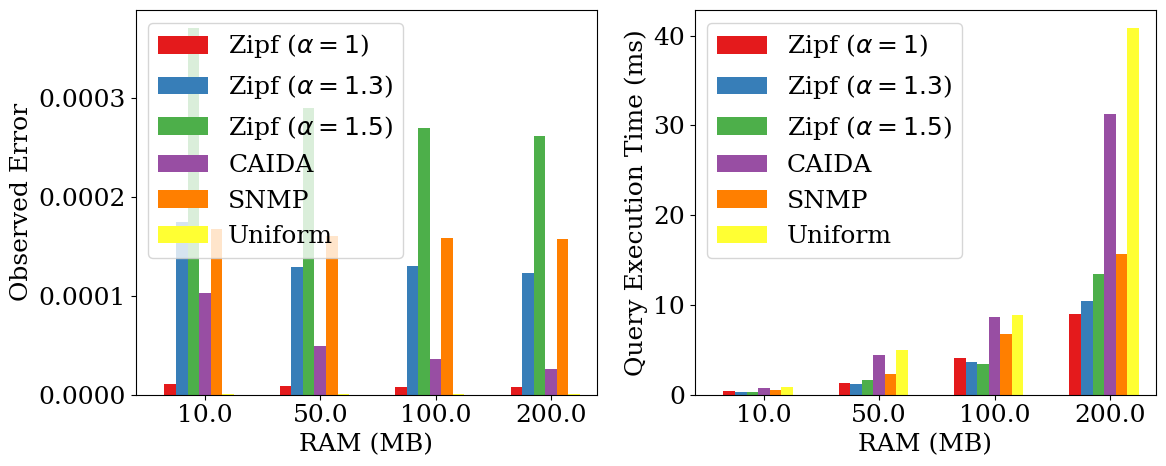

In [21]:
dataframes = [df_zipf1, df_zipf13, df_zipf15, df_caida, df_snmp, df_unif]
df_names = [r'Zipf ($\alpha = 1$)', r'Zipf ($\alpha = 1.3$)', r"Zipf ($\alpha = 1.5$)", "CAIDA", "SNMP", "Uniform"]

# List of RAM categories (four points)
ram_categories = [10, 50, 100, 200]

# Create two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Set width of the bars
bar_width = 0.1

# Set color cycle for different bars
ax1.set_prop_cycle(plt.cycler('color', plt.cm.Set1.colors))
ax2.set_prop_cycle(plt.cycler('color', plt.cm.Set1.colors))

# Initialize custom legend handles and labels for ax1 and ax2
legend_handles_ax1 = []
legend_handles_ax2 = []
legend_labels_ax1 = []
legend_labels_ax2 = []

rampos = {10:1, 50:2, 100:3, 200:4}

# Plot the bar charts for each dataframe
for i, df in enumerate(dataframes):
    # Filter the DataFrame to only include the specified RAM categories
    dfp5 = df[df['numPredicates'] == 3]
    filtered_df = dfp5[dfp5['RAM'].isin(ram_categories)]
    
    # Group the filtered DataFrame by 'RAM' and calculate mean 'altEpsError' and 'estTime' for each group
    grouped_df = filtered_df.groupby('RAM').agg({'altEpsError': 'mean', 'estTime': 'mean'}).reset_index()
    
    # Calculate x-axis positions for the bars (offset by bar_width for each dataframe)
    x_pos1 = [rampos[ram_cat] + (bar_width * len(dataframes) / 2) + (bar_width * i) for ram_cat in grouped_df['RAM']]
    x_pos2 = [rampos[ram_cat] + (bar_width * len(dataframes) / 2) + (bar_width * i) for ram_cat in grouped_df['RAM']]
    if i == 3:
        x_label1 = [rampos[ram_cat] + (bar_width * len(dataframes) / 2) + (bar_width * i) for ram_cat in grouped_df['RAM']]
        x_label2 = [rampos[ram_cat] + (bar_width * len(dataframes) / 2) + (bar_width * i) for ram_cat in grouped_df['RAM']]
    # Plot 'altEpsError' on ax1
    bar1 = ax1.bar(x_pos1, grouped_df['altEpsError'], width=bar_width, label=df_names[i])
    legend_handles_ax1.append(bar1[0])
    legend_labels_ax1.append(df_names[i])
    
    # Plot 'estTime' on ax2
    bar2 = ax2.bar(x_pos2, grouped_df['estTime'], width=bar_width, label=df_names[i])
    legend_handles_ax2.append(bar2[0])
    legend_labels_ax2.append(df_names[i])

# Set labels and titles for ax1
ax1.set_xlabel('RAM (MB)')
ax1.set_ylabel('Observed Error')
#ax1.set_title('altEpsError for Different Dataframes')
ax1.set_xticks(x_label1)
ax1.set_xticklabels(grouped_df['RAM'])
ax1.legend(legend_handles_ax1, legend_labels_ax1, loc='upper left')

# Set labels and titles for ax2
ax2.set_xlabel('RAM (MB)')
ax2.set_ylabel('Query Execution Time (ms)')
#ax2.set_title('Query Execution Time for Different d')
ax2.set_xticks(x_label2)
ax2.set_xticklabels(grouped_df['RAM'])
ax2.legend(legend_handles_ax2, legend_labels_ax2, loc='upper left')

# Adjust x-axis limits and layout
ax1.set_xlim(1, 5)
ax2.set_xlim(1, 5)
plt.tight_layout()

# Display the plot
plt.show()

<BarContainer object of 4 artists>
<BarContainer object of 4 artists>
<BarContainer object of 4 artists>
<BarContainer object of 4 artists>
<BarContainer object of 4 artists>
<BarContainer object of 4 artists>
<BarContainer object of 4 artists>
<BarContainer object of 4 artists>
<BarContainer object of 4 artists>
<BarContainer object of 4 artists>
<BarContainer object of 4 artists>
<BarContainer object of 4 artists>
<BarContainer object of 4 artists>
<BarContainer object of 4 artists>
<BarContainer object of 4 artists>
<BarContainer object of 4 artists>
<BarContainer object of 4 artists>


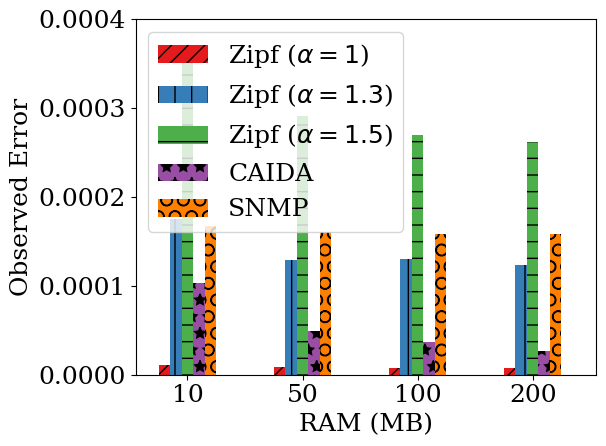

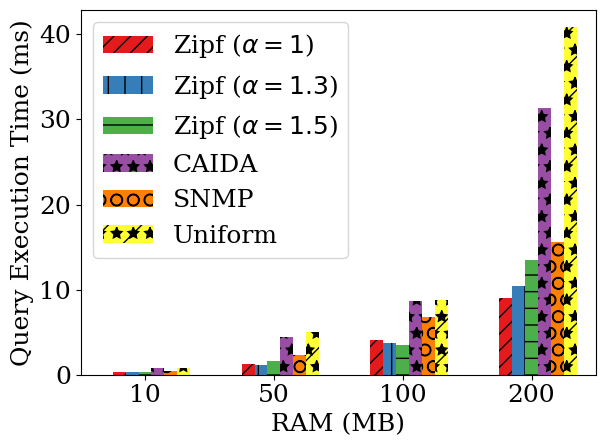

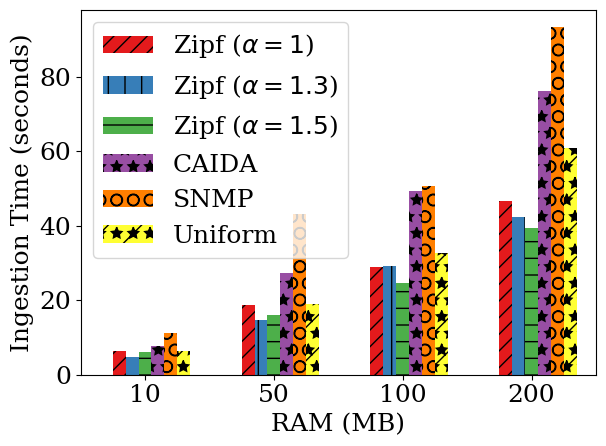

In [22]:
dataframes = [df_zipf1, df_zipf13, df_zipf15, df_caida, df_snmp, df_unif]
df_names = [r'Zipf ($\alpha = 1$)', r'Zipf ($\alpha = 1.3$)', r"Zipf ($\alpha = 1.5$)", "CAIDA", "SNMP", "Uniform"]

def create_bar_plots(dataframes, df_names, ram_categories, aggr, aggr_name, ylim=0):
    # Create subplots side by side
    fig, (ax1) = plt.subplots()

    # Set width of the bars
    bar_width = 0.1

    # Set color cycle for different bars
    ax1.set_prop_cycle(plt.cycler('hatch', ['/', '\\', 'x', 'o', '.', '+', '|', '-', '*', 'O'])
                          * plt.cycler('color', plt.cm.Set1.colors))
    #*+-./OX\ox|
    hatch_patterns = ['//', '|', '-', '*', 'O', '/*']

    # Initialize custom legend handles and labels for ax1 and ax2
    legend_handles_ax1 = []
    legend_labels_ax1 = []

    rampos = {10: 1, 50: 2, 100: 3, 200: 4}

    # Plot the bar charts for each dataframe
    for i, df in enumerate(dataframes):
        if aggr_name == 'Observed Error' and 'Uniform' in df_names[i]:
            continue
        # Filter the DataFrame to only include the specified RAM categories
        dfp5 = df[df['numPredicates'] == 3]
        filtered_df = dfp5[dfp5['RAM'].isin(ram_categories)]

        # Group the filtered DataFrame by 'RAM' and calculate the mean of 'aggr' for each group
        grouped_df = filtered_df.groupby('RAM').agg({aggr: 'mean'}).reset_index()

        # Calculate x-axis positions for the bars (offset by bar_width for each dataframe)
        num_x = len(dataframes)
        if aggr_name == 'Observed Error':
            num_x -=1
        x_pos1 = [rampos[ram_cat] + (bar_width * num_x / 2) + (bar_width * i) for ram_cat in grouped_df['RAM']]
        if i == 2:
            x_label1 = [rampos[ram_cat] +
                        (bar_width * num_x / 2) +
                        (bar_width * i) for ram_cat in grouped_df['RAM']]

        # Plot 'aggr' on ax1
        bar1 = ax1.bar(x_pos1, grouped_df[aggr], width=bar_width, label=df_names[i],hatch=hatch_patterns[i % len(hatch_patterns)] )
        print(bar1)
        legend_handles_ax1.append(bar1[0])
        legend_labels_ax1.append(df_names[i])

    # Set labels and titles for ax1
    ax1.set_xlabel('RAM (MB)')
    ax1.set_ylabel(aggr_name)
    ax1.set_xticks(x_label1)
    xlabels = grouped_df['RAM'].astype(int)
    ax1.set_xticklabels(xlabels)
    ax1.legend(legend_handles_ax1, legend_labels_ax1, loc='upper left')

    # Adjust x-axis limits and layout
    ax1.set_xlim(1, 5)
    if (ylim!=0):
        ax1.set_ylim(0, 0.0004)
    plt.tight_layout()
    fig.savefig(folder_name + "{}_{}.pdf".format("Distributed", aggr_name), format="pdf", bbox_inches="tight")

# Call the function for 'altEpsError'
create_bar_plots(dataframes, df_names, ram_categories, 'altEpsError', 'Observed Error', ylim=4)

# Call the function for 'estTime'
create_bar_plots(dataframes, df_names, ram_categories, 'estTime', 'Query Execution Time (ms)')
create_bar_plots(dataframes, df_names, ram_categories, 'Ingestion Time', 'Ingestion Time (seconds)')

In [15]:
df_zipf2['exactAnswer'].describe()

NameError: name 'df_zipf2' is not defined

In [16]:
for i, df in enumerate(dataframes):
    # Filter the DataFrame to only include the specified RAM categories
    dfp5 = df[df['numPredicates'] == 3]
    filtered_df = dfp5[dfp5['RAM'].isin(ram_categories)]
    
    # Group the filtered DataFrame by 'RAM' and calculate mean 'altEpsError' and 'estTime' for each group
    grouped_df = filtered_df.groupby('RAM').agg({'Avg Update Time': 'mean'}).reset_index()
    print(i)
    print(grouped_df)

0
     RAM  Avg Update Time
0   10.0         0.001122
1   50.0         0.003036
2  100.0         0.005224
3  200.0         0.008586
1
     RAM  Avg Update Time
0   10.0         0.001287
1   50.0         0.002853
2  100.0         0.005137
3  200.0         0.007613
2
     RAM  Avg Update Time
0   10.0         0.000951
1   50.0         0.002194
2  100.0         0.005073
3  200.0         0.005999
3
Empty DataFrame
Columns: [RAM, Avg Update Time]
Index: []
4
Empty DataFrame
Columns: [RAM, Avg Update Time]
Index: []
5
     RAM  Avg Update Time
0   10.0         0.001133
1   50.0         0.003329
2  100.0         0.007701
3  200.0         0.012587


In [17]:
# List of dataframes
dataframes = [df_zipf, df_unif, df_diff, df_caida, df_snmp]
df_names = ["Zipf1.5", "Uniform", "ZipfVar", "CAIDA", "SNMP"]

# List of RAM categories (four points)
ram_categories = [10, 50, 100, 200]

# Create two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Set width of the bars
bar_width = 0.2

# Set color cycle for different bars
ax1.set_prop_cycle(plt.cycler('color', plt.cm.Set1.colors))
ax2.set_prop_cycle(plt.cycler('color', plt.cm.Set1.colors))

# Plot the bar charts for each RAM category
for i, ram_cat in enumerate(ram_categories):
    # Initialize custom legend handles and labels for each subplot
    legend_handles_ax1 = []
    legend_handles_ax2 = []
    legend_labels_ax1 = []
    legend_labels_ax2 = []
    
    # Iterate over dataframes and plot the bars for the current RAM category
    for j, df in enumerate(dataframes):
        # Filter the DataFrame to only include the current RAM category
        filtered_df = df[df['RAM'] == ram_cat]
        
        # Calculate x-axis position for the bars
        x_pos = [j - (bar_width * len(dataframes) / 2) + (bar_width * k) for k in range(len(filtered_df))]
        
        # Plot 'altEpsError' on ax1
        bar1 = ax1.bar(x_pos, filtered_df['altEpsError'], width=bar_width, label=df_names[j])
        legend_handles_ax1.append(bar1[0])
        legend_labels_ax1.append(df_names[j])
        
        # Plot 'estTime' on ax2
        bar2 = ax2.bar(x_pos, filtered_df['estTime'], width=bar_width, label=df_names[j])
        legend_handles_ax2.append(bar2[0])
        legend_labels_ax2.append(df_names[j])
    
    # Set labels and titles for ax1
    ax1.set_xlabel('Dataframes')
    ax1.set_ylabel('altEpsError')
    ax1.set_title(f'RAM = {ram_cat}')
    ax1.set_xticks(range(len(dataframes)))
    ax1.set_xticklabels(df_names)
    
    # Add a legend to ax1
    ax1.legend(legend_handles_ax1, legend_labels_ax1, loc='upper left')
    
    # Set labels and titles for ax2
    ax2.set_xlabel('Dataframes')
    ax2.set_ylabel('estTime')
    ax2.set_title(f'RAM = {ram_cat}')
    ax2.set_xticks(range(len(dataframes)))
    ax2.set_xticklabels(df_names)
    
    # Add a legend to ax2
    ax2.legend(legend_handles_ax2, legend_labels_ax2, loc='upper left')

# Adjust layout to prevent overlapping of subplots
plt.tight_layout()

# Display the plot
plt.show()

NameError: name 'df_zipf' is not defined

In [18]:
dataframes = [df_zipf, df_unif, df_diff, df_caida, df_snmp]
df_names = ["Zipf1.5", "Uniform", "ZipfVar", "CAIDA", "SNMP"]

# List of RAM categories (four points)
ram_categories = [10, 50, 100, 200]

# Create four subplots
fig, axs = plt.subplots(1, 4, figsize=(15, 5), sharey=True)

# Set width of the bars
bar_width = 0.1

# Set color cycle for different bars
axs[0].set_prop_cycle(plt.cycler('color', plt.cm.Set1.colors))
axs[1].set_prop_cycle(plt.cycler('color', plt.cm.Set1.colors))
axs[2].set_prop_cycle(plt.cycler('color', plt.cm.Set1.colors))
axs[3].set_prop_cycle(plt.cycler('color', plt.cm.Set1.colors))

# Plot the bar charts for each RAM category
for i, ram_cat in enumerate(ram_categories):
    # Initialize custom legend handles and labels for each subplot
    legend_handles = []
    legend_labels = []
    
    # Iterate over dataframes and plot the bars for the current RAM category
    for j, df in enumerate(dataframes):
        # Filter the DataFrame to only include the current RAM category
        filtered_df = df[df['RAM'] == ram_cat]
        
        # Calculate x-axis position for the bars
        x_pos = [j - (bar_width * len(dataframes) / 2) + (bar_width * k) for k in range(len(filtered_df))]
        
        # Plot 'altEpsError' on the current subplot
        bar = axs[i].bar(x_pos, filtered_df['altEpsError'], width=bar_width, label=df_names[j])
        legend_handles.append(bar[0])
        legend_labels.append(df_names[j])
    
    # Set labels and titles for the current subplot
    axs[i].set_xlabel('Dataframes')
    axs[i].set_title(f'RAM = {ram_cat}')
    axs[i].set_xticks(range(len(dataframes)))
    axs[i].set_xticklabels(df_names)
    
    # Add a legend to the current subplot
    axs[i].legend(legend_handles, legend_labels, loc='upper left')

# Set common y-axis label for all subplots
fig.text(0.06, 0.5, 'altEpsError', va='center', rotation='vertical')

# Adjust layout to prevent overlapping of subplots
plt.tight_layout()

# Display the plot
plt.show()

NameError: name 'df_zipf' is not defined

In [94]:
df1 = df_unif[df_unif['numAttributesInWorkload'] ==0]
# Calculate the mean estTime per histSetting per numPredicates per numAttributesInWorkload

grouped_df = df1.groupby(['histSetting', 'numPredicates', 'numAttributesInWorkload'])['estTime'].mean().reset_index()

# Rename columns
grouped_df = grouped_df.rename(columns={
    'histSetting': 'setting',
    'numPredicates': 'p',
    #'numAttributesInWorkload': 'Indexed Attributes',
    'estTime': 'Query Execution Time'
})

# Pivot the DataFrame to get the desired format
pivot_df = grouped_df.pivot(index='setting', columns='p', values='Query Execution Time')

# Sort the columns by 'p'
pivot_df = pivot_df.reindex(sorted(pivot_df.columns), axis=1)

# Generate the LaTeX table
latex_table = pivot_df.to_latex(float_format="%.2f", na_rep='-', multicolumn_format='c', multicolumn=True, column_format='l|ll|', index_names=False)

# Print the LaTeX table
print(latex_table)

\begin{tabular}{l|ll|}
\toprule
{} &     2 &     3 &     4 &     5 \\
\midrule
OmniSketch10.0  &  0.63 &  0.63 &  0.66 &  0.79 \\
OmniSketch100.0 &  9.20 &  8.94 &  9.36 & 11.47 \\
OmniSketch200.0 & 23.06 & 22.50 & 23.09 & 25.47 \\
OmniSketch50.0  &  3.37 &  3.33 &  3.51 &  4.41 \\
\bottomrule
\end{tabular}



C:\Users\s162378\AppData\Local\Temp\ipykernel_11012\1718412347.py:21: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex_table = pivot_df.to_latex(float_format="%.2f", na_rep='-', multicolumn_format='c', multicolumn=True, column_format='l|ll|', index_names=False)


In [84]:
pipeline(df_zipf)

OmniSketch for 10
Avg abs error / N: 5.89517819706503e-07
Avg ingestion time: 0.0005423999999999985
Avg execution time: 0.429769392033543
OmniSketch for 50
Avg abs error / N: 3.593291404612183e-07
Avg ingestion time: 0.0014574000000000132
Avg execution time: 1.9937106918238994
OmniSketch for 100
Avg abs error / N: 5.186582809224352e-07
Avg ingestion time: 0.0025268000000000282
Avg execution time: 4.389937106918239
OmniSketch for 200
Avg abs error / N: 3.9706498951782245e-07
Avg ingestion time: 0.00606440000000005
Avg execution time: 21.89937106918239


In [93]:
filename = file_unif
df_unif = read(dataset, True)
p = 2
df_unif = preprocess(df_unif, p, True)


[]


In [79]:
pipeline(df_unif)

OmniSketch for 10
Avg abs error / N: 4.2593320235756747e-07
Avg ingestion time: 0.0006465999999999975
Avg execution time: 0.787819253438114
OmniSketch for 50
Avg abs error / N: 4.1257367387033697e-07
Avg ingestion time: 0.0021345999999999882
Avg execution time: 4.408644400785855
OmniSketch for 100
Avg abs error / N: 4.074656188605139e-07
Avg ingestion time: 0.004523199999999962
Avg execution time: 11.467583497053045
OmniSketch for 200
Avg abs error / N: 3.4931237721021896e-07
Avg ingestion time: 0.008185999999999928
Avg execution time: 25.467583497053045


In [72]:

def tableForMb(df, ram):
    df = df[df['RAM'] == ram]
    omni = df[df['setting'] == 'OmniSketch']
    hydra = df[df['setting'] == 'Hydra']
    
    print("OmniSketch for {}".format(ram))
    compute_avg(omni)
    
    #print("Hydra for {}".format(ram))
    #compute_avg(hydra)
    
def compute_avg(df):
    print("Avg abs error / N: " + str(df['altEpsError'].mean()))
    print("Avg ingestion time: " + str(df['Avg Update Time'].mean()))
    print("Avg execution time: " + str(df['estTime'].mean()))

    
def pipeline(df):
    df = df[df['numPredicates'] == df['numPredicates'].max()]
    tableForMb(df, 10)
    tableForMb(df, 50)
    tableForMb(df, 100)
    tableForMb(df, 200)


pipeline(df)

OmniSketch for 10
Avg abs error / N: 4.2593320235756747e-07
Avg ingestion time: 0.0006465999999999975
Avg execution time: 0.787819253438114
OmniSketch for 50
Avg abs error / N: 4.1257367387033697e-07
Avg ingestion time: 0.0021345999999999882
Avg execution time: 4.408644400785855
OmniSketch for 100
Avg abs error / N: 4.074656188605139e-07
Avg ingestion time: 0.004523199999999962
Avg execution time: 11.467583497053045
OmniSketch for 200
Avg abs error / N: 3.4931237721021896e-07
Avg ingestion time: 0.008185999999999928
Avg execution time: 25.467583497053045


In [43]:
df['RAM'].unique()

array([ 10.,  50., 100., 200.])

In [44]:
def tableForMb(df, ram, setting):
    df = df[(df['RAM'] == ram) & (df['setting'] == setting)]
    
    avg_abs_error = df['altEpsError'].mean()
    avg_ingestion_time = df['Avg Update Time'].mean()
    avg_execution_time = df['estTime'].mean()

    # Assemble the LaTeX table content for a single row
    table_row = f"{setting} & {ram}MB & {avg_abs_error:.3f} & {avg_ingestion_time:.3f} & {avg_execution_time:.3f} \\\\\n"
    return table_row

def compute_avg(df):
    avg_abs_error = df['altEpsError'].mean()
    avg_ingestion_time = df['Avg Update Time'].mean()
    avg_execution_time = df['estTime'].mean()

    # Print the average values (optional)
    print("Avg abs error / N:", avg_abs_error)
    print("Avg ingestion time:", avg_ingestion_time)
    print("Avg execution time:", avg_execution_time)

    # Return the average values as a dictionary
    return {
        'abs_error_avg': avg_abs_error,
        'ingestion_time_avg': avg_ingestion_time,
        'execution_time_avg': avg_execution_time
    }

def pipeline(df):
    df = df[df['numPredicates'] == df['numPredicates'].max()]
    omni_10 = tableForMb(df, 10, 'OmniSketch')
    omni_50 = tableForMb(df, 50, 'OmniSketch')
    omni_100 = tableForMb(df, 100, 'OmniSketch')
    hydra_10 = tableForMb(df, 10, 'Hydra')
    hydra_50 = tableForMb(df, 50, 'Hydra')
    hydra_100 = tableForMb(df, 100, 'Hydra')

    # Assemble the complete LaTeX table
    latex_table = r"""
\begin{table}[]
\begin{tabular}{l|lll|lll|}
\cline{2-7}
                                 & \multicolumn{3}{c|}{Accuracy}                                 & \multicolumn{3}{c|}{Execution Time}                           \\ \hline
\multicolumn{1}{|l|}{Synopsis}   & \multicolumn{1}{l|}{10MB} & \multicolumn{1}{l|}{50MB} & 100MB & \multicolumn{1}{l|}{10MB} & \multicolumn{1}{l|}{50MB} & 100MB \\ \hline
\multicolumn{1}{|l|}{Hydra}      & \multicolumn{1}{l|}{}     & \multicolumn{1}{l|}{}     &       & \multicolumn{1}{l|}{}     & \multicolumn{1}{l|}{}     &       \\ \hline
""" + hydra_10 + hydra_50 + hydra_100 + r"""
\multicolumn{1}{|l|}{Omnisketch} & \multicolumn{1}{l|}{}     & \multicolumn{1}{l|}{}     &       & \multicolumn{1}{l|}{}     & \multicolumn{1}{l|}{}     &       \\ \hline
""" + omni_10 + omni_50 + omni_100 + r"""
\end{tabular}
\end{table}
"""

    # Print the complete LaTeX table
    print(latex_table)

# Call the pipeline function with your dataframe
pipeline(df)


\begin{table}[]
\begin{tabular}{l|lll|lll|}
\cline{2-7}
                                 & \multicolumn{3}{c|}{Accuracy}                                 & \multicolumn{3}{c|}{Execution Time}                           \\ \hline
\multicolumn{1}{|l|}{Synopsis}   & \multicolumn{1}{l|}{10MB} & \multicolumn{1}{l|}{50MB} & 100MB & \multicolumn{1}{l|}{10MB} & \multicolumn{1}{l|}{50MB} & 100MB \\ \hline
\multicolumn{1}{|l|}{Hydra}      & \multicolumn{1}{l|}{}     & \multicolumn{1}{l|}{}     &       & \multicolumn{1}{l|}{}     & \multicolumn{1}{l|}{}     &       \\ \hline
Hydra & 10MB & 0.000 & 0.011 & 0.015 \\
Hydra & 50MB & 0.000 & 0.011 & 0.006 \\
Hydra & 100MB & 0.000 & 0.011 & 0.006 \\

\multicolumn{1}{|l|}{Omnisketch} & \multicolumn{1}{l|}{}     & \multicolumn{1}{l|}{}     &       & \multicolumn{1}{l|}{}     & \multicolumn{1}{l|}{}     &       \\ \hline
OmniSketch & 10MB & 0.000 & 0.001 & 0.698 \\
OmniSketch & 50MB & 0.000 & 0.003 & 3.931 \\
OmniSketch & 100MB & 0.000 & 0.004 & 10.586 \\


# Plot functions

In [65]:

# Define a dictionary to map 'histSetting' to marker and color
histSetting_style_dict = {
    '$\\mathbb{S}0_{\\min}$': {'marker': 'o', 'color': 'blue'},
    '$\\mathbb{S}0_{\\cap}$': {'marker': 's', 'color': 'green'},
    '$\\mathbb{S}1 (10 MB)$': {'marker': '^', 'color': 'red'},
    '$\\mathbb{S}1 (50 MB)$': {'marker': 'D', 'color': 'purple'},
    '$\\mathbb{S}1 (100 MB)$': {'marker': 'v', 'color': 'orange'},
    '$\\mathbb{S}1 (200 MB)$': {'marker': '*', 'color': 'cyan'},
    'Hydra (10 MB)': {'marker': 'X', 'color': 'yellow'},     # Add new entry with distinct marker
    'Hydra (50 MB)': {'marker': '+', 'color': 'magenta'},    # Add new entry with distinct marker
    'Hydra (100 MB)': {'marker': 'P', 'color': 'lime'},      # Add new entry with distinct marker
    'Hydra (200 MB)': {'marker': 'H', 'color': 'crimson'},
    'OmniSketch_2':{'marker': '*', 'color': 'crimson'},
    'OmniSketch_3':{'marker': 'v', 'color': 'crimson'},
    'Hydra_2':{'marker': 'P', 'color': 'crimson'},
    'Hydra_3':{'marker': 'H', 'color': 'crimson'},
    'OmniSketch_2_50':{'marker': '*', 'color': 'crimson'},
    'OmniSketch_3_50':{'marker': 'v', 'color': 'crimson'},
    'Hydra_2_50':{'marker': 'P', 'color': 'crimson'},
    'Hydra_3_50':{'marker': 'H', 'color': 'crimson'},
    'OmniSketch_2_100':{'marker': '*', 'color': 'crimson'},
    'OmniSketch_3_100':{'marker': 'v', 'color': 'crimson'},
    'Hydra_2_100':{'marker': 'P', 'color': 'crimson'},
    'Hydra_3_100':{'marker': 'H', 'color': 'crimson'}# Add new entry with distinct marker
}

# Define a dictionary to map 'aggr' to linestyle
aggr_dict = {
    'altEpsError': '-',
    'IT': '--',
    'execTime': ':'
}

# Get the unique MB values from the 'histSetting' column
unique_MB_values = [int(x.split(' ')[1].replace('(', '')) for x in df['histSetting'] if 'MB' in x]

# Calculate the normalized values for the color map
normalized_MB = [(MB - min(unique_MB_values)) / (max(unique_MB_values) - min(unique_MB_values)) for MB in unique_MB_values]



# Function to get color based on 'histSetting'
def get_color(histSetting, psetting = False):
    if psetting:
        if 'Hydra' in histSetting:
        # Create a color map based on the MB values
            color_map = cm.get_cmap('plasma')
        elif 'Omni' in histSetting:
            color_map = cm.get_cmap('Greys')
        else:
            print("No colormap defined for setting {}".format(histSetting))
        p = int(histSetting.split('_')[1].replace('_', ''))
        normalized_p_value = (p - 2) / (1)
        return color_map(normalized_p_value)
    
    if '{S}0' in histSetting:
        return histSetting_style_dict.get(histSetting)['color']
    if 'Hydra' in histSetting:
        # Create a color map based on the MB values
        color_map = cm.get_cmap('tab20')
    elif '{S}1' in histSetting:
        color_map = cm.get_cmap('viridis')
    else:
        print("No colormap defined for setting {}".format(histSetting))
    MB = int(histSetting.split(' ')[1].replace('(', ''))
    normalized_MB_value = (MB - min(unique_MB_values)) / (max(unique_MB_values) - min(unique_MB_values))
    return color_map(normalized_MB_value)


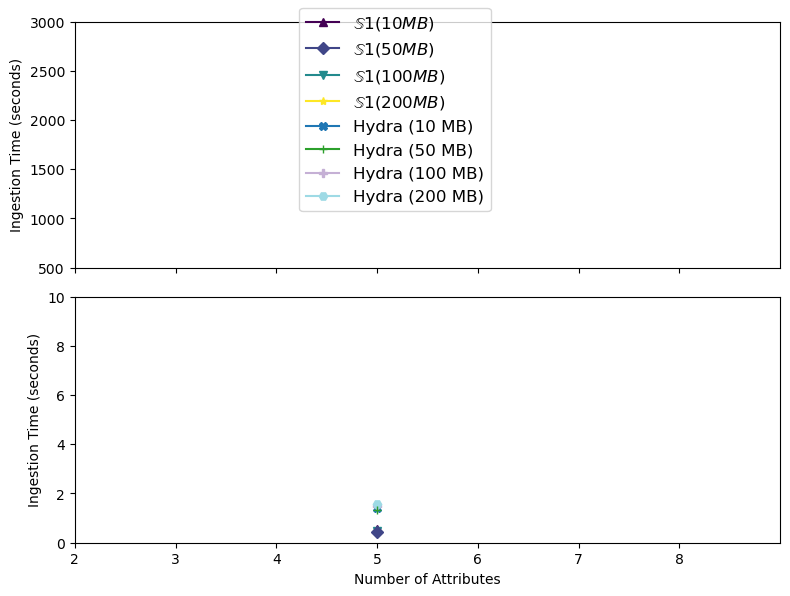

In [66]:
def extract_x_from_setting(setting):
    # Extract the numeric value of "x" from the setting
    if 'Hydra' in setting:
        return 1000*int(setting.split(' (')[1].split(' MB)')[0])
    else:
        return int(setting.split(' (')[1].split(' MB)')[0])
def plot_ingest(df):
    grouped_df = df.groupby(['numAttributesInWorkload', 'histSetting', 'RAM', 'streamSize'])['Avg Update Time'].mean().reset_index()

    # Create a plot with broken y-axis
    fig, (ax2, ax1) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

    # Initialize a dictionary to keep track of plotted labels
    plotted_labels = {}

    # Iterate over unique combinations of 'setting' and 'RAM'
    for i, ((setting, RAM), data) in enumerate(grouped_df.groupby(['histSetting', 'RAM'])):
        # Filter the data for the current combination of 'setting' and 'RAM'
        style = histSetting_style_dict.get(setting, {'marker': 'o'})
        filtered_data = data[['numAttributesInWorkload', 'Avg Update Time', 'streamSize']]

        # Plot the data on the upper y-axis (500-3000 scale)
        line2, = ax2.plot(filtered_data['numAttributesInWorkload'],
                          filtered_data['Avg Update Time']*filtered_data['streamSize']/1000,
                          label=f'{setting}',
                          color=get_color(setting),
                          marker=style['marker'])
        plotted_labels[setting] = line2

        # Plot the data on the lower y-axis (0-100 scale)
        line1, = ax1.plot(filtered_data['numAttributesInWorkload'],
                          filtered_data['Avg Update Time']*filtered_data['streamSize']/1000,
                          label=f'{setting}',
                          color=get_color(setting),
                          marker=style['marker'])

    # Set labels and title for the upper y-axis (500-3000 scale)
    ax2.set_ylabel('Ingestion Time (seconds)')
    ax2.set_ylim(500, 3000)

    # Set labels and title for the lower y-axis (0-100 scale)
    ax1.set_ylabel('Ingestion Time (seconds)')
    ax1.set_ylim(0, 10)
    ax1.set_yticks(range(0, 11, 20))

    # Add a break line between the two y-axis scales
    ax1.set_yscale('function', functions=(lambda x: x*10, lambda x: x/10))

    # Set x-ticks
    x_ticks = filtered_data['numAttributesInWorkload'].tolist()
    ax2.set_xticks(x_ticks)

    # Set the x-axis limits for both ax1 and ax2
    ax1.set_xlim(2, 9)
    ax2.set_xlim(2, 9)

    plt.xticks(range(2, 9))
    # Create a single combined legend outside the plots
    lines = [plotted_labels[setting] for setting in sorted(plotted_labels, key=extract_x_from_setting)]
    labels = [line.get_label() for line in lines]
    fig.legend(lines, labels, loc='upper center', fontsize='large')

    # Display the plot
    plt.xlabel('Number of Attributes')
    plt.tight_layout()
    plt.show()

    fig.savefig(folder_name + "{}_{}.pdf".format("Compare_IT", dataset), format="pdf", bbox_inches="tight")

# Call the function
plot_ingest(df)

In [67]:
# Query Execution Time
### y-axis: query execution time
### x-axis: Memory of sketch
### Show for 3 different values of p


In [68]:
filename = "output/results_Compare Baselines_synth_2023-07-26.csv"

In [69]:
df = read(dataset, True)
df = preprocess(df,2, True)
#df = df[df['numAttributes'] == df['numAttributes'].max()]

['timestamp', 'frameNumber', 'ethSrc', 'ethDst', 'ipSrc']


In [70]:
wls3 = df[df['numAttributesInWorkload'] == df['numAttributesInWorkload'].min() + 1]
ids = wls3['queryID'].unique()

df_small_wl = df[df['queryID'].isin(ids)]

In [71]:
def plot_ex_time(df):
    
    dfram = df[df['RAM']==df['RAM'].unique().min()]
    grouped_df = dfram.groupby(['numAttributesInWorkload', 'RAM', 'numPredicates', 'setting'])['estTime'].mean().reset_index()
   
    # Set up the plot
    fig, ax = plt.subplots()

    # Iterate over unique combinations of 'numPredicates' and 'setting'
    for i, ((num_predicates, setting), data) in enumerate(grouped_df.groupby(['numPredicates', 'setting'])):
        # Filter the data for the current combination of 'numPredicates' and 'setting'
        p_setting = setting + "_"+ str(num_predicates)
        style = histSetting_style_dict.get(p_setting, {'marker': 'o'})
        
        filtered_data = data[['numAttributesInWorkload', 'estTime']]

        # Plot the data
        ax.plot(filtered_data['numAttributesInWorkload'], filtered_data['estTime'],
                label=f'p = {num_predicates}, {setting}', color = get_color(p_setting, True), marker = style['marker'])
        
        

    # Set labels and title
    ax.set_xlabel('Number of Attributes')
    ax.set_ylabel('Avg. Execution Time (milliseconds)')
    title = 'Avg. Execution Time vs. numAttributesInWorkload'
    #ax.set_title(title)

    # Add a legend
    ax.legend(fontsize='large')
    x_ticks = filtered_data['numAttributesInWorkload'].tolist()
    ax.set_xticks(x_ticks)
    # Display the plot
    plt.show()
    
    fig.savefig(folder_name + "{}_{}.pdf".format(title.replace(" ", "_"), dataset), format="pdf", bbox_inches="tight" )
    

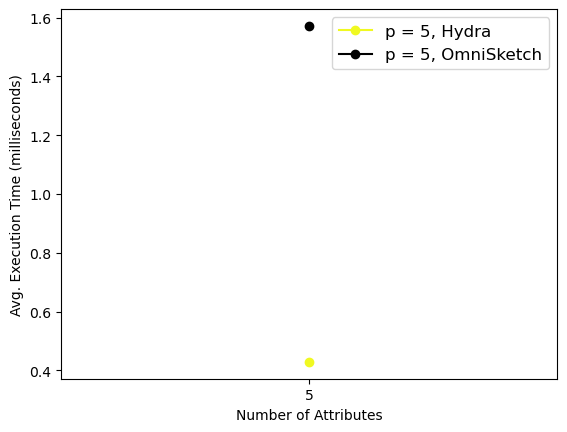

In [72]:
plot_ex_time(df)

# Accuracy
### y-axis abs error / N
### X-axis searchable attrs p
### For different vals of RAM

In [73]:
filename = "output/results_Compare Baselines_synth_2023-07-26.csv"

In [74]:
df = read(dataset, True)
df = preprocess(df,2, True)

['timestamp', 'frameNumber', 'ethSrc', 'ethDst', 'ipSrc']


In [75]:
wls = df[df['numAttributesInWorkload'] == df['numAttributesInWorkload'].min()]
ids = wls['queryID'].unique()
wls3 = df[df['numAttributesInWorkload'] == df['numAttributesInWorkload'].min() + 1]
ids3 = wls3['queryID'].unique()

df_small_wl = df[df['queryID'].isin(ids3)]

In [76]:
def plot_acc(df):
    #df = df[df['RAM'] == 10]
    
    grouped_df = df.groupby(['numAttributesInWorkload', 'RAM', 'numPredicates', 'setting'])['altEpsError'].mean().reset_index()
    

    # Set up the plot
    fig, ax = plt.subplots()

    # Iterate over unique combinations of 'numPredicates' and 'setting'
    for i, ((num_predicates, setting, ram), data) in enumerate(grouped_df.groupby(['numPredicates', 'setting', 'RAM'])):
        # Filter the data for the current combination of 'numPredicates' and 'setting'
        print(num_predicates, setting, ram)
        p_ram_setting = setting + "_"+ str(num_predicates)# + "_"+ str(ram)
        style = histSetting_style_dict.get(p_ram_setting, {'marker': 'o'})
        filtered_data = data[['numAttributesInWorkload', 'altEpsError']]

        # Plot the data
        ax.plot(filtered_data['numAttributesInWorkload'], filtered_data['altEpsError'],linestyle='-', linewidth=1,
                label=f'p = {num_predicates}, {setting}, {ram}', color = get_color(p_ram_setting, True), marker = style['marker'])
        """
        if i > 0:
            prev_filtered_data = grouped_df.iloc[i-1][['numAttributesInWorkload', 'altEpsError']]
            ax.plot([prev_filtered_data['numAttributesInWorkload']], [filtered_data['altEpsError']],
                    linestyle='-', linewidth=1, color = get_color(p_ram_setting, True), marker = style['marker'])
        """
    # Set labels and title
    ax.set_xlabel('Number of Attributes')
    ax.set_ylabel('Avg. abs. error / N')
    title = 'Accuracy vs. num Attributes'
    #ax.set_title(title)

    # Add a legend
    #ax.legend(fontsize='large',loc= 0)
    # Shrink current axis by 20%
    #box = ax.get_position()
    #ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])

    # Put a legend to the right of the current axis
    ax.legend(loc='upper left', fontsize='large')#, bbox_to_anchor=(1, 0.5))
    x_ticks = filtered_data['numAttributesInWorkload'].tolist()
    ax.set_xticks(x_ticks)
    
    # Set the x-axis limits for both ax1 and ax2
    ax.set_xlim(2, 8)

    plt.xticks(range(2, 8))
    # Display the plot
    plt.show()
    
    fig.savefig(folder_name + "{}_{}.pdf".format(title.replace(" ", "_"), dataset), format="pdf", bbox_inches="tight" )
    

5 Hydra 10.0
5 Hydra 50.0
5 Hydra 100.0
5 Hydra 200.0
5 OmniSketch 10.0
5 OmniSketch 50.0
5 OmniSketch 100.0
5 OmniSketch 200.0


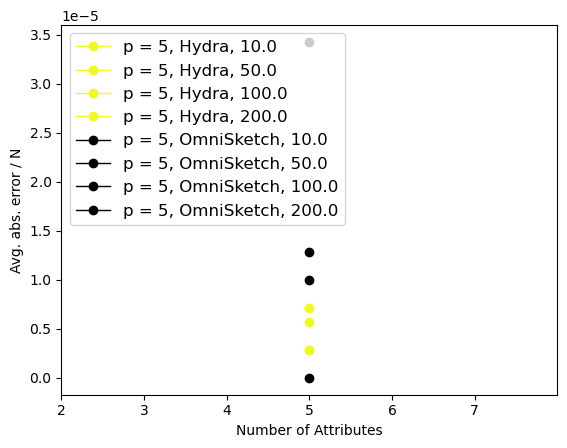

In [77]:
plot_acc(df)

# Cardinality analysis

In [6]:
path = "C:/Users/s162378/OneDrive - TU Eindhoven/Documents/GitHub/DSCM/inputData/data/Zipf/"

In [52]:
name_zipf1 = "synthDataset_synthzipf1_N=5000000_ZipfAttrs=5_zipfAlpha=1.0_differAlphas=false.csv"
name_zipf13 = "synthDataset_synthzipf1-3_N=5000000_ZipfAttrs=5_zipfAlpha=1.3_differAlphas=false.csv"
name_zipf15 = "synthDataset_synthzipf1-5_N=5000000_ZipfAttrs=5_zipfAlpha=1.5_differAlphas=false.csv"

In [42]:
def ppZipf(data):
    df = pd.DataFrame(data)
    
    # Split and convert to numeric
    numeric_df = df.iloc[:,0].str.strip('[]').str.split(', ', expand=True).apply(pd.to_numeric)

    # Rename the columns as needed (you can change column names as per your requirement)
    numeric_df.columns = ['Column2', 'Column3', 'Column4', 'Column5', 'Column6']

    return numeric_df

        

In [48]:
def get_card(name):
    df = pd.read_csv(path + name)
    df1 = ppZipf(df.iloc[:,5])
    cardinality = df1.nunique()
    print("{} has {}".format(name, cardinality))
    return df1


In [53]:
zipf1 = get_card(name_zipf1)
zipf13 = get_card(name_zipf13)
zipf15 = get_card(name_zipf15)


synthDataset_synthzipf1_N=5000000_ZipfAttrs=5_zipfAlpha=1.0_differAlphas=false.csv has Column2    10000
Column3    10000
Column4    10000
Column5    10000
Column6    10000
dtype: int64
synthDataset_synthzipf1-3_N=5000000_ZipfAttrs=5_zipfAlpha=1.3_differAlphas=false.csv has Column2    10000
Column3    10000
Column4    10000
Column5    10000
Column6    10000
dtype: int64
synthDataset_synthzipf1-5_N=5000000_ZipfAttrs=5_zipfAlpha=1.5_differAlphas=false.csv has Column2    9689
Column3    9707
Column4    9716
Column5    9678
Column6    9694
dtype: int64
